In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter1d

Outcome: AMD
Data: GBD 2021
Step: 3. Figure
weze_code_ver

```
step1. Scaling
step2. Figure

In [2]:
# load
pop_df=pd.read_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/population/pop_2050.csv")
forecast_final=pd.read_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/forecast_final_ui.csv") 
forecast_final

,sex_name,age_name,year,smoke_cate,omega,mrbrt_arc_ensemble,mrbrt_arc_ensemble_lower,mrbrt_arc_ensemble_upper,finalprev_arc_ensemble,finalprev_arc_ensemble_lower,finalprev_arc_ensemble_upper
0,Female,All ages,1990,Mean Per Day,0.0,4.404975,4.145391,4.664559,4.404975,4.145391,4.664559
1,Female,All ages,1991,Mean Per Day,0.0,4.422290,4.162706,4.681874,4.422290,4.162706,4.681874
2,Female,All ages,1992,Mean Per Day,0.0,4.437326,4.177742,4.696909,4.437326,4.177742,4.696909
3,Female,All ages,1993,Mean Per Day,0.0,4.450161,4.190577,4.709745,4.450161,4.190577,4.709745
4,Female,All ages,1994,Mean Per Day,0.0,4.460874,4.201290,4.720458,4.460874,4.201290,4.720458
...,...,...,...,...,...,...,...,...,...,...,...
727,Male,All ages,2046,Mean Per Day,2.5,4.291491,3.916112,4.666870,4.384012,3.933456,4.834567
728,Male,All ages,2047,Mean Per Day,2.5,4.287997,3.912618,4.663376,4.380516,3.929961,4.831071
729,Male,All ages,2048,Mean Per Day,2.5,4.284503,3.909124,4.659882,4.377021,3.926465,4.827576
730,Male,All ages,2049,Mean Per Day,2.5,4.281009,3.905631,4.656388,4.373525,3.922970,4.824081


In [3]:
# re-log transform
columns_to_reverse = ['mrbrt_arc_ensemble', 'mrbrt_arc_ensemble_lower', 'mrbrt_arc_ensemble_upper', 'finalprev_arc_ensemble', 'finalprev_arc_ensemble_lower', 'finalprev_arc_ensemble_upper']
# expm1 (log1p의 반대 연산)
for col in columns_to_reverse:
    forecast_final[col] = np.expm1(forecast_final[col])

forecast_final.to_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/forecast_re_rate.csv") 
forecast_final

,sex_name,age_name,year,smoke_cate,omega,mrbrt_arc_ensemble,mrbrt_arc_ensemble_lower,mrbrt_arc_ensemble_upper,finalprev_arc_ensemble,finalprev_arc_ensemble_lower,finalprev_arc_ensemble_upper
0,Female,All ages,1990,Mean Per Day,0.0,80.857115,62.142324,105.118795,80.857115,62.142324,105.118795
1,Female,All ages,1991,Mean Per Day,0.0,82.286781,63.245129,106.972199,82.286781,63.245129,106.972199
2,Female,All ages,1992,Mean Per Day,0.0,83.548515,64.218396,108.607900,83.548515,64.218396,108.607900
3,Female,All ages,1993,Mean Per Day,0.0,84.640696,65.060874,110.023793,84.640696,65.060874,110.023793
4,Female,All ages,1994,Mean Per Day,0.0,85.563119,65.772405,111.219613,85.563119,65.772405,111.219613
...,...,...,...,...,...,...,...,...,...,...,...
727,Male,All ages,2046,Mean Per Day,2.5,72.075351,49.204876,105.364308,79.158948,50.083223,124.784095
728,Male,All ages,2047,Mean Per Day,2.5,71.820480,49.029773,104.993333,78.879246,49.904976,124.345191
729,Male,All ages,2048,Mean Per Day,2.5,71.566499,48.855280,104.623652,78.600520,49.727351,123.907818
730,Male,All ages,2049,Mean Per Day,2.5,71.313403,48.681396,104.255260,78.322766,49.550346,123.471972


In [4]:
# omega = 1.0
filtered_forecast = forecast_final[forecast_final['omega'] == 1.0]
filtered_forecast.to_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/filtered_forecast.csv", index=False)
filtered_forecast

,sex_name,age_name,year,smoke_cate,omega,mrbrt_arc_ensemble,mrbrt_arc_ensemble_lower,mrbrt_arc_ensemble_upper,finalprev_arc_ensemble,finalprev_arc_ensemble_lower,finalprev_arc_ensemble_upper
244,Female,All ages,1990,Mean Per Day,1.0,80.857115,62.142324,105.118795,80.857115,62.142324,105.118795
245,Female,All ages,1991,Mean Per Day,1.0,82.286781,63.245129,106.972199,82.286781,63.245129,106.972199
246,Female,All ages,1992,Mean Per Day,1.0,83.548515,64.218396,108.607900,83.548515,64.218396,108.607900
247,Female,All ages,1993,Mean Per Day,1.0,84.640696,65.060874,110.023793,84.640696,65.060874,110.023793
248,Female,All ages,1994,Mean Per Day,1.0,85.563119,65.772405,111.219613,85.563119,65.772405,111.219613
...,...,...,...,...,...,...,...,...,...,...,...
361,Male,All ages,2046,Mean Per Day,1.0,106.312109,72.726517,155.197378,117.419777,74.465859,184.822354
362,Male,All ages,2047,Mean Per Day,1.0,107.142545,73.297051,156.406113,118.343055,75.054240,186.271146
363,Male,All ages,2048,Mean Per Day,1.0,107.979407,73.871999,157.624202,119.273531,75.647209,187.731234
364,Male,All ages,2049,Mean Per Day,1.0,108.822745,74.451397,158.851717,120.211262,76.244800,189.202705


In [5]:
pop_df = pop_df.loc[:, ~pop_df.columns.str.contains('^Unnamed')]
pop_df.head()

,location_name,sex_name,age_name,year,pop_val
0,Global,Male,45-49 years,1990,119393459.9
1,Global,Male,45-49 years,1991,121055600.8
2,Global,Male,45-49 years,1992,125409740.5
3,Global,Male,45-49 years,1993,129913892.2
4,Global,Male,45-49 years,1994,136563981.7


In [6]:
# Filter pop_df for rows where age_name is "All ages" and location_name is "Global"
filtered_pop_df = pop_df[(pop_df["age_name"] == "All ages") & (pop_df["location_name"] == "Global")]
filtered_pop_df.to_csv("C:/Users/psy09/Desktop/Lab/5.AMD(GBD_database)/2.revision/prediction_model/data/filtered_pop_df.csv", index=False)
filtered_pop_df

,location_name,sex_name,age_name,year,pop_val
30744,Global,Female,All ages,1990,5.825324e+08
30745,Global,Female,All ages,1991,5.928578e+08
30746,Global,Female,All ages,1992,6.054258e+08
30747,Global,Female,All ages,1993,6.178148e+08
30748,Global,Female,All ages,1994,6.317656e+08
...,...,...,...,...,...
30861,Global,Male,All ages,2046,1.776266e+09
30862,Global,Male,All ages,2047,1.796204e+09
30863,Global,Male,All ages,2048,1.815981e+09
30864,Global,Male,All ages,2049,1.835686e+09


Mrbrt-ARC-PAF ensemble (total)

In [7]:
# Separate male and female data
male_data = filtered_forecast[filtered_forecast['sex_name'] == 'Male']
female_data = filtered_forecast[filtered_forecast['sex_name'] == 'Female']

# Gaussian_smoothing
def apply_gaussian_smoothing_in_range(data, column, start_year, end_year, sigma):
    subset = data[(data['year'] >= start_year) & (data['year'] <= end_year)]
    smoothed_values = gaussian_filter1d(subset[column], sigma)
    data.loc[(data['year'] >= start_year) & (data['year'] <= end_year), column] = smoothed_values
    return data

def preprocess_data(data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma):
    for column in columns_to_smooth:
        data = apply_gaussian_smoothing_in_range(data, column, smoothing_start_year, smoothing_end_year, sigma)
    before_2021 = data[data['year'] <= 2021]
    after_2021 = data[data['year'] > 2021]
    return before_2021, after_2021

In [8]:
# Plot (male/female)
def plot_male_female_forecast(
    male_before, male_after, female_before, female_after, 
    y_column, lower_column, upper_column, title="", save_path=None
):
    y_min = min(male_before[lower_column].min(), female_before[lower_column].min())
    y_max = max(male_after[upper_column].max(), female_after[upper_column].max())

    plt.figure(figsize=(6, 6))
    plt.rcParams['font.family'] = 'Times New Roman'
    ax = plt.gca()
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Male
    plt.plot(male_before['year'], male_before[y_column], '-', color='royalblue', label='Male: GBD 2021 estimates')
    plt.plot(male_after['year'], male_after[y_column], '--', color='royalblue', label='Male: Forecasted estimates')
    plt.fill_between(
        pd.concat([male_before, male_after])['year'],
        pd.concat([male_before, male_after])[lower_column],
        pd.concat([male_before, male_after])[upper_column],
        alpha=0.2, color='royalblue'
    )
    # Female
    plt.plot(female_before['year'], female_before[y_column], '-', color='darkorange', label='Female: GBD 2021 estimates')
    plt.plot(female_after['year'], female_after[y_column], '--', color='darkorange', label='Female: Forecasted estimates')
    plt.fill_between(
        pd.concat([female_before, female_after])['year'],
        pd.concat([female_before, female_after])[lower_column],
        pd.concat([female_before, female_after])[upper_column],
        alpha=0.2, color='darkorange'
    )

    plt.xlabel('Year', fontsize=18)
    plt.ylabel('Rate (per 100 000 population)', fontsize=17)
    plt.xticks(np.arange(1990, 2051,10))
    plt.xlim(1990, 2050)
    plt.ylim(0, 220)
    plt.tick_params(axis='y', labelsize=15)
    plt.tick_params(axis='x', labelsize=15)

    # plt.legend(loc='lower right', frameon=False, fontsize=11)
    plt.title(title, fontsize=20)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1000, bbox_inches='tight') 
    plt.show()

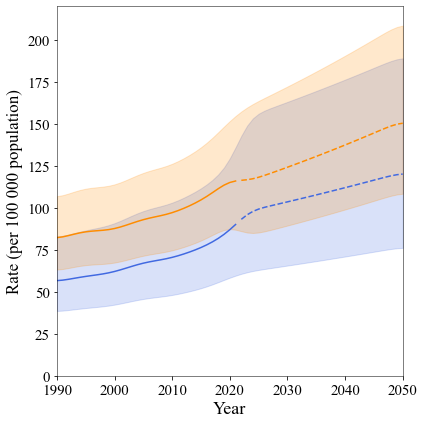

In [9]:
# run (main)
columns_to_smooth = ['finalprev_arc_ensemble', 'finalprev_arc_ensemble_lower', 'finalprev_arc_ensemble_upper']
smoothing_start_year = 1990
smoothing_end_year = 2050
sigma_value = 1.9

# Male
male_before, male_after = preprocess_data(male_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
# Female
female_before, female_after = preprocess_data(female_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
# save
save_path = r"C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\2.revision\prediction_model\prediction_figure\forecast_rate_both.png"
plot_male_female_forecast(
    male_before, male_after, female_before, female_after,
    y_column='finalprev_arc_ensemble', 
    lower_column='finalprev_arc_ensemble_lower', 
    upper_column='finalprev_arc_ensemble_upper',
    save_path=save_path
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


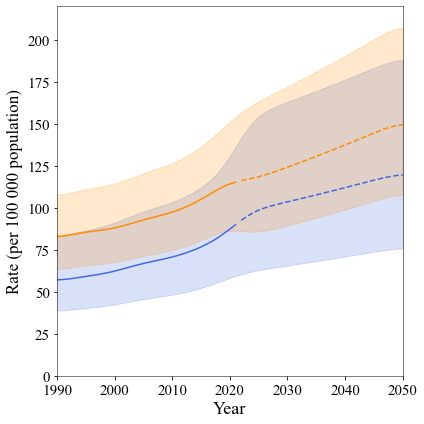

✅ 파일 저장 완료:
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\forecast_rate_both.png
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\forecast_rate_both.eps
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\forecast_rate_both.pdf


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📌 저장 경로 설정
output_dir = r"C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector"
os.makedirs(output_dir, exist_ok=True)  # 폴더가 없으면 생성

output_path_base = os.path.join(output_dir, "forecast_rate_both")

# 📌 Plot function (Times New Roman 적용 + EPS, PDF 저장 추가)
def plot_male_female_forecast(
    male_before, male_after, female_before, female_after, 
    y_column, lower_column, upper_column, title="", save_path=None
):
    y_min = min(male_before[lower_column].min(), female_before[lower_column].min())
    y_max = max(male_after[upper_column].max(), female_after[upper_column].max())

    # 📌 Times New Roman 폰트 설정
    plt.rcParams['font.family'] = 'Times New Roman'
    
    # 📌 플롯 생성
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Male
    ax.plot(male_before['year'], male_before[y_column], '-', color='royalblue', label='Male: GBD 2021 estimates')
    ax.plot(male_after['year'], male_after[y_column], '--', color='royalblue', label='Male: Forecasted estimates')
    ax.fill_between(
        pd.concat([male_before, male_after])['year'],
        pd.concat([male_before, male_after])[lower_column],
        pd.concat([male_before, male_after])[upper_column],
        alpha=0.2, color='royalblue'
    )
    # Female
    ax.plot(female_before['year'], female_before[y_column], '-', color='darkorange', label='Female: GBD 2021 estimates')
    ax.plot(female_after['year'], female_after[y_column], '--', color='darkorange', label='Female: Forecasted estimates')
    ax.fill_between(
        pd.concat([female_before, female_after])['year'],
        pd.concat([female_before, female_after])[lower_column],
        pd.concat([female_before, female_after])[upper_column],
        alpha=0.2, color='darkorange'
    )

    ax.set_xlabel('Year', fontsize=18)
    ax.set_ylabel('Rate (per 100 000 population)', fontsize=17)
    ax.set_xticks(np.arange(1990, 2051,10))
    ax.set_xlim(1990, 2050)
    ax.set_ylim(0, 220)
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=15)

    ax.set_title(title, fontsize=20)

    plt.tight_layout()

    # 📌 파일 저장 (PNG, EPS, PDF)
    if save_path:
        fig.savefig(save_path + ".png", format='png', dpi=1000, bbox_inches='tight')
        fig.savefig(save_path + ".eps", format='eps', dpi=1000, bbox_inches='tight')
        fig.savefig(save_path + ".pdf", format='pdf', dpi=1000, bbox_inches='tight')

    plt.show()

# 📌 데이터 전처리
columns_to_smooth = ['finalprev_arc_ensemble', 'finalprev_arc_ensemble_lower', 'finalprev_arc_ensemble_upper']
smoothing_start_year = 1990
smoothing_end_year = 2050
sigma_value = 1.9

# Male
male_before, male_after = preprocess_data(male_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
# Female
female_before, female_after = preprocess_data(female_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)

# 📌 그래프 저장 실행
plot_male_female_forecast(
    male_before, male_after, female_before, female_after,
    y_column='finalprev_arc_ensemble', 
    lower_column='finalprev_arc_ensemble_lower', 
    upper_column='finalprev_arc_ensemble_upper',
    save_path=output_path_base  # PNG, EPS, PDF 저장
)

print(f"✅ 파일 저장 완료:\n"
      f"- {output_path_base}.png\n"
      f"- {output_path_base}.eps\n"
      f"- {output_path_base}.pdf")


ARC-MR-brt-PAF ensemble

In [11]:
# Separate male and female data
male_data = filtered_forecast[filtered_forecast['sex_name'] == 'Male']
female_data = filtered_forecast[filtered_forecast['sex_name'] == 'Female']

# Gaussian_smoothing
def apply_gaussian_smoothing_in_range(data, column, start_year, end_year, sigma):
    subset = data[(data['year'] >= start_year) & (data['year'] <= end_year)]
    smoothed_values = gaussian_filter1d(subset[column], sigma)
    data.loc[(data['year'] >= start_year) & (data['year'] <= end_year), column] = smoothed_values
    return data

def preprocess_data(data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma):
    for column in columns_to_smooth:
        data = apply_gaussian_smoothing_in_range(data, column, smoothing_start_year, smoothing_end_year, sigma)
    before_2021 = data[data['year'] <= 2021]
    after_2021 = data[data['year'] > 2021]
    return before_2021, after_2021

In [12]:
# Plot (male/female)
def plot_male_female_forecast(
    male_before, male_after, female_before, female_after, 
    y_column, lower_column, upper_column, title="", save_path=None
):
    y_min = min(male_before[lower_column].min(), female_before[lower_column].min())
    y_max = max(male_after[upper_column].max(), female_after[upper_column].max())

    plt.figure(figsize=(8, 6))
    plt.rcParams['font.family'] = 'Times New Roman'
    ax = plt.gca()
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Male
    plt.plot(male_before['year'], male_before[y_column], '-', color='royalblue', label='Male: GBD 2021 estimates')
    plt.plot(male_after['year'], male_after[y_column], '--', color='royalblue', label='Male: Forecasted estimates')
    plt.fill_between(
        pd.concat([male_before, male_after])['year'],
        pd.concat([male_before, male_after])[lower_column],
        pd.concat([male_before, male_after])[upper_column],
        alpha=0.2, color='royalblue'
    )
    # Female
    plt.plot(female_before['year'], female_before[y_column], '-', color='darkorange', label='Female: GBD 2021 estimates')
    plt.plot(female_after['year'], female_after[y_column], '--', color='darkorange', label='Female: Forecasted estimates')
    plt.fill_between(
        pd.concat([female_before, female_after])['year'],
        pd.concat([female_before, female_after])[lower_column],
        pd.concat([female_before, female_after])[upper_column],
        alpha=0.16, color='darkorange'
    )

    plt.xlabel('Year', fontsize=18)
    plt.ylabel('Rate (per 100 000 population)', fontsize=18)
    plt.xticks(np.arange(1990, 2051,10))
    plt.xlim(1990, 2050)
    plt.ylim(0, y_max + 10)
    plt.tick_params(axis='y', labelsize=15)
    plt.tick_params(axis='x', labelsize=15)

    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=12)
    plt.title(title, fontsize=20)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1000, bbox_inches='tight') 
    plt.show()

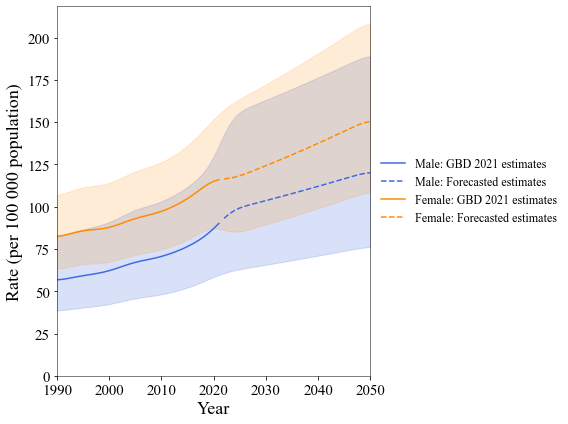

In [13]:
# run (main)
columns_to_smooth = ['finalprev_arc_ensemble', 'finalprev_arc_ensemble_lower', 'finalprev_arc_ensemble_upper']
smoothing_start_year = 1990
smoothing_end_year = 2050
sigma_value = 2.0

# Male
male_before, male_after = preprocess_data(male_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
# Female
female_before, female_after = preprocess_data(female_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
# save
save_path = r"C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\2.revision\prediction_model\prediction_figure\forecast_graph_.png"
plot_male_female_forecast(
    male_before, male_after, female_before, female_after,
    y_column='finalprev_arc_ensemble', 
    lower_column='finalprev_arc_ensemble_lower', 
    upper_column='finalprev_arc_ensemble_upper',
    save_path=save_path
)

Sex-split

In [14]:
# Plot for single gender with two ensembles
def plot_ensemble_comparison_single_gender(
    gender_before, gender_after,
    y1_column, y2_column,
    lower1_column, upper1_column,
    lower2_column, upper2_column,
    title="", save_path=None
):
    y_min = min(
        gender_before[lower1_column].min(),
        gender_before[lower2_column].min(),
        gender_after[lower1_column].min(),
        gender_after[lower2_column].min(),
    )
    y_max = max(
        gender_before[upper1_column].max(),
        gender_before[upper2_column].max(),
        gender_after[upper1_column].max(),
        gender_after[upper2_column].max(),
    )

    plt.figure(figsize=(6, 6))
    plt.rcParams['font.family'] = 'Times New Roman'
    ax = plt.gca()
    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Ensemble 1
    plt.plot(gender_before['year'], gender_before[y1_column], '-', color='#ffb700')
    plt.plot(gender_after['year'], gender_after[y1_column], '--', color='#ffb700', label= 'Female estimates with risk')
    plt.fill_between(
        pd.concat([gender_before, gender_after])['year'],
        pd.concat([gender_before, gender_after])[lower1_column],
        pd.concat([gender_before, gender_after])[upper1_column],
        alpha=0.2, color='#ffb700'
    )
    # Ensemble 2
    plt.plot(gender_before['year'], gender_before[y2_column], '-', color='#ff7844')
    plt.plot(gender_after['year'], gender_after[y2_column], '--', color='#ff7844', label='Female estimates without risk')
    plt.fill_between(
        pd.concat([gender_before, gender_after])['year'],
        pd.concat([gender_before, gender_after])[lower2_column],
        pd.concat([gender_before, gender_after])[upper2_column],
        alpha=0.2, color='#ff7844'
    )

    plt.xlabel('Year', fontsize=18)
    plt.ylabel('Rate (per 100 000 population)', fontsize=17)
    plt.xticks(np.arange(1990, 2051, 10))
    plt.xlim(1990, 2050)
    plt.ylim(0, 220)
    plt.tick_params(axis='y', labelsize=15)
    plt.tick_params(axis='x', labelsize=15)

    # plt.legend(loc='lower right', frameon=False, fontsize=12)
    plt.title(title, fontsize=20)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1000, bbox_inches='tight') 
    plt.show()

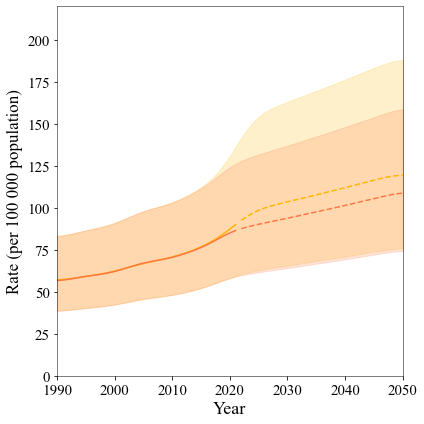

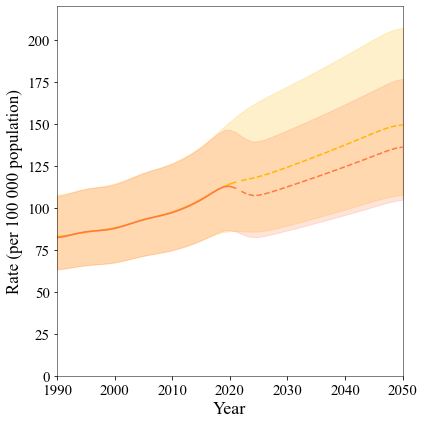

In [15]:
smoothing_start_year = 1990
smoothing_end_year = 2050
sigma_value = 1.9

# Male
columns_to_smooth = [
    'finalprev_arc_ensemble', 'finalprev_arc_ensemble_lower', 'finalprev_arc_ensemble_upper',
    'mrbrt_arc_ensemble', 'mrbrt_arc_ensemble_lower', 'mrbrt_arc_ensemble_upper'
]
male_before, male_after = preprocess_data(male_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
plot_ensemble_comparison_single_gender(
    male_before, male_after,
    y1_column='finalprev_arc_ensemble', y2_column='mrbrt_arc_ensemble',
    lower1_column='finalprev_arc_ensemble_lower', upper1_column='finalprev_arc_ensemble_upper',
    lower2_column='mrbrt_arc_ensemble_lower', upper2_column='mrbrt_arc_ensemble_upper',
    save_path="male_rate_comparison.png"
)
# Female
female_before, female_after = preprocess_data(female_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
plot_ensemble_comparison_single_gender(
    female_before, female_after,
    y1_column='finalprev_arc_ensemble', y2_column='mrbrt_arc_ensemble',
    lower1_column='finalprev_arc_ensemble_lower', upper1_column='finalprev_arc_ensemble_upper',
    lower2_column='mrbrt_arc_ensemble_lower', upper2_column='mrbrt_arc_ensemble_upper',
    save_path="female_rate_comparison.png"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


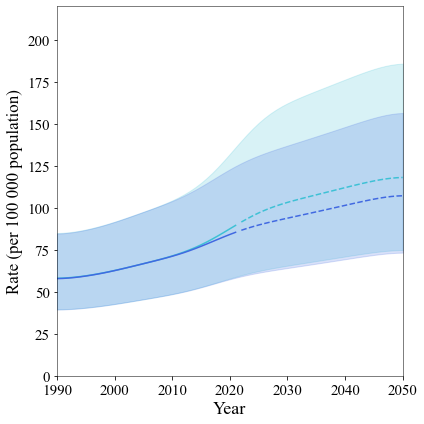

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


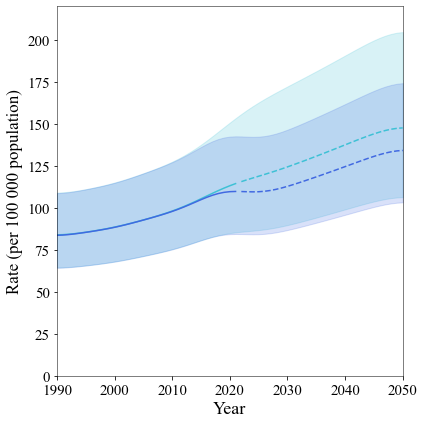

✅ 파일 저장 완료:
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\male_rate_comparison.png
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\male_rate_comparison.eps
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\male_rate_comparison.pdf
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\female_rate_comparison.png
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\female_rate_comparison.eps
- C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector\female_rate_comparison.pdf


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 📌 저장 경로 설정
output_dir = r"C:\Users\psy09\Desktop\Lab\5.AMD(GBD_database)\4.proof\figure_vector"
os.makedirs(output_dir, exist_ok=True)  # 폴더가 없으면 생성

# 📌 Plot function (Times New Roman 적용 + EPS, PDF 저장 추가)
def plot_ensemble_comparison_single_gender(
    gender_before, gender_after,
    y1_column, y2_column,
    lower1_column, upper1_column,
    lower2_column, upper2_column,
    title="", save_path=None
):
    y_min = min(
        gender_before[lower1_column].min(),
        gender_before[lower2_column].min(),
        gender_after[lower1_column].min(),
        gender_after[lower2_column].min(),
    )
    y_max = max(
        gender_before[upper1_column].max(),
        gender_before[upper2_column].max(),
        gender_after[upper1_column].max(),
        gender_after[upper2_column].max(),
    )

    # 📌 Times New Roman 폰트 설정
    plt.rcParams['font.family'] = 'Times New Roman'
    
    # 📌 플롯 생성
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['top'].set_linewidth(0.5)

    # Ensemble 1
    ax.plot(gender_before['year'], gender_before[y1_column], '-', color='#3ec1d5')
    ax.plot(gender_after['year'], gender_after[y1_column], '--', color='#3ec1d5', label='Estimates with risk')
    ax.fill_between(
        pd.concat([gender_before, gender_after])['year'],
        pd.concat([gender_before, gender_after])[lower1_column],
        pd.concat([gender_before, gender_after])[upper1_column],
        alpha=0.2, color='#3ec1d5'
    )
    # Ensemble 2
    ax.plot(gender_before['year'], gender_before[y2_column], '-', color='royalblue')
    ax.plot(gender_after['year'], gender_after[y2_column], '--', color='royalblue', label='Estimates without risk')
    ax.fill_between(
        pd.concat([gender_before, gender_after])['year'],
        pd.concat([gender_before, gender_after])[lower2_column],
        pd.concat([gender_before, gender_after])[upper2_column],
        alpha=0.2, color='royalblue'
    )

    ax.set_xlabel('Year', fontsize=18)
    ax.set_ylabel('Rate (per 100 000 population)', fontsize=17)
    ax.set_xticks(np.arange(1990, 2051, 10))
    ax.set_xlim(1990, 2050)
    ax.set_ylim(0, 220)
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=15)

    ax.set_title(title, fontsize=20)

    plt.tight_layout()

    # 📌 파일 저장 (PNG, EPS, PDF)
    if save_path:
        fig.savefig(save_path + ".png", format='png', dpi=1000, bbox_inches='tight')
        fig.savefig(save_path + ".eps", format='eps', dpi=1000, bbox_inches='tight')
        fig.savefig(save_path + ".pdf", format='pdf', dpi=1000, bbox_inches='tight')

    plt.show()

# 📌 데이터 전처리
smoothing_start_year = 1990
smoothing_end_year = 2050
sigma_value = 1.9

columns_to_smooth = [
    'finalprev_arc_ensemble', 'finalprev_arc_ensemble_lower', 'finalprev_arc_ensemble_upper',
    'mrbrt_arc_ensemble', 'mrbrt_arc_ensemble_lower', 'mrbrt_arc_ensemble_upper'
]

# 📌 Male 데이터 처리 및 저장
male_before, male_after = preprocess_data(male_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
male_save_path = os.path.join(output_dir, "male_rate_comparison")
plot_ensemble_comparison_single_gender(
    male_before, male_after,
    y1_column='finalprev_arc_ensemble', y2_column='mrbrt_arc_ensemble',
    lower1_column='finalprev_arc_ensemble_lower', upper1_column='finalprev_arc_ensemble_upper',
    lower2_column='mrbrt_arc_ensemble_lower', upper2_column='mrbrt_arc_ensemble_upper',
    save_path=male_save_path
)

# 📌 Female 데이터 처리 및 저장
female_before, female_after = preprocess_data(female_data, columns_to_smooth, smoothing_start_year, smoothing_end_year, sigma_value)
female_save_path = os.path.join(output_dir, "female_rate_comparison")
plot_ensemble_comparison_single_gender(
    female_before, female_after,
    y1_column='finalprev_arc_ensemble', y2_column='mrbrt_arc_ensemble',
    lower1_column='finalprev_arc_ensemble_lower', upper1_column='finalprev_arc_ensemble_upper',
    lower2_column='mrbrt_arc_ensemble_lower', upper2_column='mrbrt_arc_ensemble_upper',
    save_path=female_save_path
)

print(f"✅ 파일 저장 완료:\n"
      f"- {male_save_path}.png\n"
      f"- {male_save_path}.eps\n"
      f"- {male_save_path}.pdf\n"
      f"- {female_save_path}.png\n"
      f"- {female_save_path}.eps\n"
      f"- {female_save_path}.pdf")


Non-Gaussian smoothing

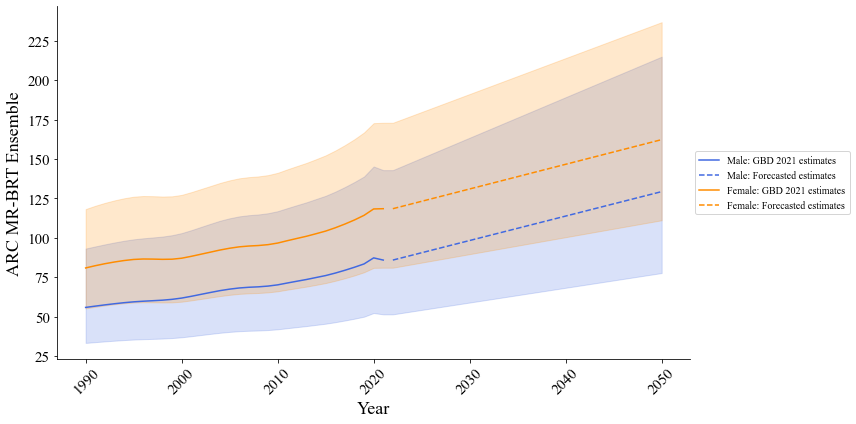

In [159]:
male_data = filtered_forecast[filtered_forecast['sex_name'] == 'Male'].sort_values(by='year').copy()
female_data = filtered_forecast[filtered_forecast['sex_name'] == 'Female'].sort_values(by='year').copy()
male_before = male_data[male_data['year'] <= 2021]
male_after = male_data[male_data['year'] > 2021]
female_before = female_data[female_data['year'] <= 2021]
female_after = female_data[female_data['year'] > 2021]

# 선형 보간법
def linear_transition(before, after, column):
    start_value = before[column].iloc[-1]
    end_value = after[column].iloc[-1]
    after.loc[:, column] = np.linspace(start_value, end_value, len(after))

columns_to_adjust = ['mrbrt_arc_ensemble', 'mrbrt_arc_ensemble_lower', 'mrbrt_arc_ensemble_upper']
for column in columns_to_adjust:
    linear_transition(male_before, male_after, column)
    linear_transition(female_before, female_after, column)

y_min = min(male_before['mrbrt_arc_ensemble_lower'].min(), female_before['mrbrt_arc_ensemble_lower'].min())
y_max = max(male_after['mrbrt_arc_ensemble_upper'].max(), female_after['mrbrt_arc_ensemble_upper'].max())

plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Male
plt.plot(male_before['year'], male_before['mrbrt_arc_ensemble'], '-', color='royalblue', label='Male: GBD 2021 estimates')
plt.plot(male_after['year'], male_after['mrbrt_arc_ensemble'], '--', color='royalblue', label='Male: Forecasted estimates')
plt.fill_between(
    pd.concat([male_before, male_after])['year'],
    pd.concat([male_before, male_after])['mrbrt_arc_ensemble_lower'],
    pd.concat([male_before, male_after])['mrbrt_arc_ensemble_upper'],
    alpha=0.2, color='royalblue'
)
# Female
plt.plot(female_before['year'], female_before['mrbrt_arc_ensemble'], '-', color='darkorange', label='Female: GBD 2021 estimates')
plt.plot(female_after['year'], female_after['mrbrt_arc_ensemble'], '--', color='darkorange', label='Female: Forecasted estimates')
plt.fill_between(
    pd.concat([female_before, female_after])['year'],
    pd.concat([female_before, female_after])['mrbrt_arc_ensemble_lower'],
    pd.concat([female_before, female_after])['mrbrt_arc_ensemble_upper'],
    alpha=0.2, color='darkorange'
)

plt.xlabel('Year', fontsize=18)
plt.ylabel('ARC MR-BRT Ensemble', fontsize=18)
plt.xticks(np.arange(1990, 2051, 10), rotation=45)
plt.ylim(y_min - 10, y_max + 10)  # y축 범위 조정
plt.tick_params(axis='y', labelsize=15)
plt.tick_params(axis='x', labelsize=15)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()